# Task 7 : Describe and Interpret the Preliminary eICU Clusters

This notebook describes the selected preliminary clustering solution using the original clinical variables.

The notebook produces :
- A cluster-sze summary.
- One presentation-ready cluster-characteristics table.
- Numerical descriptive-statistics tables.
- Standardozed cluster profiles.
- The variables that most strongly distinguish each cluster.
- Brief descriptive interpretations
- A cluster-size figure.
- A standardized cluster-profile heatmap.
- Top-distinguishing-variable plots.
- Optional exploratory outcome comparisons when valid outcome coluumns are available.

THe notebook does not refit KMeans or select a new value of `k`.

### Import Required Libraries

In [1]:
from pathlib import Path
from IPython.display import display
import re
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    chi2_contingency,
    mannwhitneyu,
    kruskal,
)


# Improve DataFrame display
pd.set_option(
    "display.max_columns",
    120,
)

pd.set_option(
    "display.max_rows",
    200,
)

pd.set_option(
    "display.width",
    180,
)


# Plot appearance
sns.set_theme(
    style="whitegrid"
)


# Hide unimportant warnings
warnings.filterwarnings(
    "ignore"
)


print(
    "All required libraries were imported successfully."
)

All required libraries were imported successfully.


#### Explanation :
This cell imports the libraries used for data processing, descriptive statistics, figures and optional exploratory outcome comparisons.

### Locate the Project Root and Create Folders

In [2]:
CURRENT_DIR = Path.cwd().resolve()

if (
    (CURRENT_DIR / "data").exists()
    and (CURRENT_DIR / "notebooks").exists()
):
    ROOT_DIR = CURRENT_DIR

elif (
    CURRENT_DIR.name == "module_2"
    and CURRENT_DIR.parent.name == "notebooks"
):
    ROOT_DIR = CURRENT_DIR.parents[1]

elif CURRENT_DIR.name == "notebooks":
    ROOT_DIR = CURRENT_DIR.parent

else:
    raise FileNotFoundError(
        "The project root could not be identified. "
        "Run this notebook from the project root, "
        "notebooks folder, or notebooks/module_2 folder."
    )


# Main input folders
DATA_DIR = ROOT_DIR / "data"

PROCESSED_DIR = (
    DATA_DIR
    / "processed"
)

KMEANS_RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "kmeans_eicu"
)


# Task 7 output folders
RESULTS_DIR = (
    ROOT_DIR
    / "results"
    / "cluster_interpretation"
)

PLOTS_DIR = (
    ROOT_DIR
    / "plots"
    / "cluster_interpretation"
)

TOP_VARIABLE_PLOTS_DIR = (
    PLOTS_DIR
    / "top_variables"
)

OUTCOME_PLOTS_DIR = (
    PLOTS_DIR
    / "outcomes"
)


# Create output folders
folders_to_create = [
    RESULTS_DIR,
    PLOTS_DIR,
    TOP_VARIABLE_PLOTS_DIR,
    OUTCOME_PLOTS_DIR,
]


for folder in folders_to_create:
    folder.mkdir(
        parents=True,
        exist_ok=True,
    )


print("=" * 90)
print("TASK 7 FOLDERS")
print("=" * 90)
print(f"Project root       : {ROOT_DIR}")
print(f"Task 7 results     : {RESULTS_DIR}")
print(f"Task 7 plots       : {PLOTS_DIR}")
print("=" * 90)

TASK 7 FOLDERS
Project root       : C:\Users\samsa\Documents\Capstone Project\Project
Task 7 results     : C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_interpretation
Task 7 plots       : C:\Users\samsa\Documents\Capstone Project\Project\plots\cluster_interpretation


#### Explanation :
All Task 7 supporting CSV files are saved under:
```
results/cluster_interpretation/
```
All figures are saved under:
```
plots/cluster_interpretation/
```

### Define Input Files and Analysis Settings

In [3]:
# ICU stay identifier
ID_COLUMN = "patientunitstayid"

# Cluster assignment column created by the K-Means notebook
CLUSTER_COLUMN = "preliminary_cluster"


# Main input files
ANALYTIC_DATASET_PATH = (
    DATA_DIR
    / "analytic_dataset.csv"
)

ASSIGNMENTS_PATH = (
    KMEANS_RESULTS_DIR
    / "preliminary_cluster_assignments.csv"
)

CENTERS_PATH = (
    KMEANS_RESULTS_DIR
    / "preliminary_cluster_centers_standardized.csv"
)

TOP_FEATURES_PATH = (
    KMEANS_RESULTS_DIR
    / "preliminary_top_distinguishing_features.csv"
)


# Number of distinguishing variables shown per cluster
TOP_N_VARIABLES = 5


# Use median and IQR when absolute skewness exceeds this value
SKEWNESS_THRESHOLD = 1.0


# Change to False to skip optional mortality and LOS comparisons
INCLUDE_EXPLORATORY_OUTCOMES = True


# Required files
required_files = [
    ANALYTIC_DATASET_PATH,
    ASSIGNMENTS_PATH,
    CENTERS_PATH,
]


for file_path in required_files:

    if not file_path.exists():

        raise FileNotFoundError(
            f"Required input file not found:\n"
            f"{file_path}"
        )


print(
    "All required Task 7 input files were found."
)

All required Task 7 input files were found.


#### Explanation :
The notebook requires:
```
data/analytic_dataset.csv
results/kmeans_eicu/preliminary_cluster_assignments.csv
results/kmeans_eicu/preliminary_cluster_centers_standardized.csv
```
The original clinical dataset is used for means, medians, and variability. The standardized centers are used to identify the strongest distinguishing variables.

### Define the $29$ Variables, Display Names and Units

In [4]:
FEATURES = [
    # Demographics and comorbidity
    "age",
    "sex_female",
    "elixhauser_count",

    # Vital signs and neurological status
    "heart_rate",
    "respiratory_rate",
    "systolic_blood_pressure",
    "temperature",
    "oxygen_saturation",
    "gcs",

    # Inflammatory markers
    "wbc",
    "band_count",
    "esr",
    "crp",

    # Organ dysfunction markers
    "ast",
    "alt",
    "total_bilirubin",
    "bun",
    "creatinine",
    "inr",
    "pao2",
    "platelets",
    "troponin",

    # Other laboratory measurements
    "glucose",
    "sodium",
    "hemoglobin",
    "chloride",
    "bicarbonate",
    "lactate",
    "albumin",
]


VARIABLE_INFO = {
    "age": (
        "Age",
        "years",
    ),

    "sex_female": (
        "Female sex",
        "N (%)",
    ),

    "elixhauser_count": (
        "Elixhauser comorbidity count",
        "count",
    ),

    "heart_rate": (
        "Heart rate",
        "beats/min",
    ),

    "respiratory_rate": (
        "Respiratory rate",
        "breaths/min",
    ),

    "systolic_blood_pressure": (
        "Systolic blood pressure",
        "mm Hg",
    ),

    "temperature": (
        "Temperature",
        "°C",
    ),

    "oxygen_saturation": (
        "Oxygen saturation",
        "%",
    ),

    "gcs": (
        "Glasgow Coma Scale",
        "score",
    ),

    "wbc": (
        "White blood cell count",
        "×10³/µL",
    ),

    "band_count": (
        "Band count",
        "%",
    ),

    "esr": (
        "Erythrocyte sedimentation rate",
        "mm/hour",
    ),

    "crp": (
        "C-reactive protein",
        "source unit",
    ),

    "ast": (
        "AST",
        "U/L",
    ),

    "alt": (
        "ALT",
        "U/L",
    ),

    "total_bilirubin": (
        "Total bilirubin",
        "mg/dL",
    ),

    "bun": (
        "Blood urea nitrogen",
        "mg/dL",
    ),

    "creatinine": (
        "Creatinine",
        "mg/dL",
    ),

    "inr": (
        "International normalized ratio",
        "ratio",
    ),

    "pao2": (
        "Arterial PaO₂",
        "mm Hg",
    ),

    "platelets": (
        "Platelet count",
        "×10³/µL",
    ),

    "troponin": (
        "Troponin",
        "source unit",
    ),

    "glucose": (
        "Glucose",
        "mg/dL",
    ),

    "sodium": (
        "Sodium",
        "mEq/L",
    ),

    "hemoglobin": (
        "Hemoglobin",
        "g/dL",
    ),

    "chloride": (
        "Chloride",
        "mEq/L",
    ),

    "bicarbonate": (
        "Bicarbonate",
        "mEq/L",
    ),

    "lactate": (
        "Lactate",
        "mmol/L",
    ),

    "albumin": (
        "Albumin",
        "g/dL",
    ),
}


assert len(FEATURES) == 29

assert set(FEATURES) == set(
    VARIABLE_INFO
)


print(
    f"Number of clustering variables: "
    f"{len(FEATURES)}"
)

Number of clustering variables: 29


#### Explanation :
Readable variable names and units are used in the final presentation table.

`source unit` is retained for CRP and troponin because the exact unit must be confirmed from the laboratory-unit review generated during preprocessing.

### Load the Required Data

In [5]:
analytic_data = pd.read_csv(
    ANALYTIC_DATASET_PATH,
    low_memory=False,
)


assignments = pd.read_csv(
    ASSIGNMENTS_PATH,
    low_memory=False,
)


standardized_centers = pd.read_csv(
    CENTERS_PATH,
    low_memory=False,
)


# The previously saved top-feature file is optional.
if (
    TOP_FEATURES_PATH.exists()
    and TOP_FEATURES_PATH.stat().st_size > 0
):

    try:

        saved_top_features = pd.read_csv(
            TOP_FEATURES_PATH,
            low_memory=False,
        )

    except pd.errors.EmptyDataError:

        saved_top_features = pd.DataFrame()

else:

    saved_top_features = pd.DataFrame()


print(
    "Analytic dataset shape       :",
    analytic_data.shape,
)

print(
    "Cluster assignments shape    :",
    assignments.shape,
)

print(
    "Standardized centers shape   :",
    standardized_centers.shape,
)

Analytic dataset shape       : (116573, 30)
Cluster assignments shape    : (116573, 3)
Standardized centers shape   : (2, 30)


#### Explanation :
The clinical dataset contains values in understandable clinical units. The assignments connect every ICU stay to its selected preliminary cluster.

### Validate and Merge the Datasets

In [6]:
# ---------------------------------------------------------
# Check analytic-dataset columns
# ---------------------------------------------------------
required_analytic_columns = [
    ID_COLUMN,
    *FEATURES,
]


missing_analytic_columns = [
    column
    for column in required_analytic_columns
    if column not in analytic_data.columns
]


if missing_analytic_columns:

    raise ValueError(
        "The analytic dataset is missing these columns:\n"
        f"{missing_analytic_columns}"
    )


# ---------------------------------------------------------
# Check assignment columns
# ---------------------------------------------------------
required_assignment_columns = [
    ID_COLUMN,
    CLUSTER_COLUMN,
]


missing_assignment_columns = [
    column
    for column in required_assignment_columns
    if column not in assignments.columns
]


if missing_assignment_columns:

    raise ValueError(
        "The assignment file is missing these columns:\n"
        f"{missing_assignment_columns}"
    )


# ---------------------------------------------------------
# Check duplicate ICU stay identifiers
# ---------------------------------------------------------
if analytic_data[
    ID_COLUMN
].duplicated().any():

    raise ValueError(
        "The analytic dataset contains duplicate "
        "ICU stay identifiers."
    )


if assignments[
    ID_COLUMN
].duplicated().any():

    raise ValueError(
        "The assignment file contains duplicate "
        "ICU stay identifiers."
    )


# ---------------------------------------------------------
# Select assignment columns
# ---------------------------------------------------------
assignment_columns = [
    ID_COLUMN,
    CLUSTER_COLUMN,
]


if "selected_k" in assignments.columns:
    assignment_columns.append(
        "selected_k"
    )


# ---------------------------------------------------------
# Merge clinical values with cluster assignments
# ---------------------------------------------------------
cluster_data = analytic_data.merge(
    assignments[
        assignment_columns
    ],
    on=ID_COLUMN,
    how="inner",
    validate="one_to_one",
)


# Every assignment must match one analytic-dataset row
if len(cluster_data) != len(assignments):

    raise ValueError(
        "Not every cluster assignment matched an "
        "analytic-dataset row. Review "
        "patientunitstayid alignment."
    )


if cluster_data[
    CLUSTER_COLUMN
].isna().any():

    raise ValueError(
        "Missing cluster assignments remain after merging."
    )


cluster_data[
    CLUSTER_COLUMN
] = (
    cluster_data[
        CLUSTER_COLUMN
    ]
    .astype(int)
)


CLUSTERS = sorted(
    cluster_data[
        CLUSTER_COLUMN
    ]
    .unique()
    .tolist()
)


SELECTED_K = len(
    CLUSTERS
)


# Save the merged Task 7 data
cluster_data.to_csv(
    RESULTS_DIR
    / "analytic_dataset_with_clusters.csv",
    index=False,
)


print(
    "Merged dataset shape:",
    cluster_data.shape,
)

print(
    "Selected clusters    :",
    CLUSTERS,
)

print(
    "Selected k           :",
    SELECTED_K,
)

Merged dataset shape: (116573, 32)
Selected clusters    : [0, 1]
Selected k           : 2


#### Explanation :
The selected clusters are merged with the original clinical values using `patientunitstayid`.

K-Means is not fitted again in this notebook.

### Calculate Cluster Sizes

In [7]:
cluster_size_summary = (
    cluster_data[
        CLUSTER_COLUMN
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "cluster"
    )
    .reset_index(
        name="icu_stay_count"
    )
)


cluster_size_summary[
    "icu_stay_percent"
] = (
    cluster_size_summary[
        "icu_stay_count"
    ]
    / len(cluster_data)
    * 100
)


cluster_size_summary.to_csv(
    RESULTS_DIR
    / "cluster_size_summary.csv",
    index=False,
)


cluster_size_summary

,cluster,icu_stay_count,icu_stay_percent
0,0,32719,28.067391
1,1,83854,71.932609


#### Explanation :
This table reports the number and percentage of ICU stays assigned to every cluster.

### Create the Cluster-Size Figure

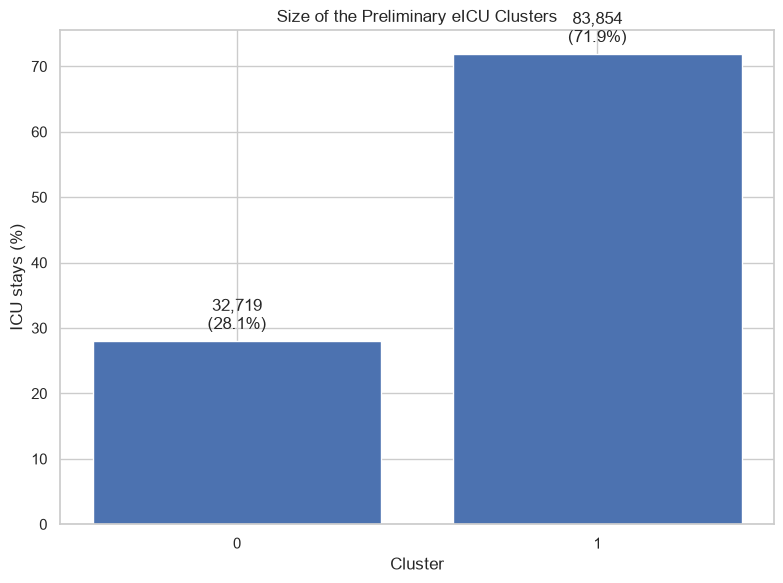

In [8]:
figure, axis = plt.subplots(
    figsize=(
        8,
        6,
    )
)


bars = axis.bar(
    cluster_size_summary[
        "cluster"
    ].astype(str),

    cluster_size_summary[
        "icu_stay_percent"
    ],
)


for bar, count, percent in zip(
    bars,
    cluster_size_summary[
        "icu_stay_count"
    ],
    cluster_size_summary[
        "icu_stay_percent"
    ],
):

    axis.annotate(
        f"{count:,}\n({percent:.1f}%)",

        (
            bar.get_x()
            + bar.get_width()
            / 2,

            bar.get_height(),
        ),

        ha="center",
        va="bottom",

        xytext=(
            0,
            5,
        ),

        textcoords="offset points",
    )


axis.set_title(
    "Size of the Preliminary eICU Clusters"
)

axis.set_xlabel(
    "Cluster"
)

axis.set_ylabel(
    "ICU stays (%)"
)


figure.tight_layout()


figure.savefig(
    PLOTS_DIR
    / "cluster_size_distribution.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
The figure clearly presents both the percentage and the number of ICU stays in each cluster.

### Build Numerical Descriptive Statistics

In [9]:
def calculate_numeric_summary(
    dataframe,
    feature,
    group_name,
    cluster_value=None,
):
    """
    Calculate detailed descriptive statistics for one variable.
    """

    series = pd.to_numeric(
        dataframe[
            feature
        ],
        errors="coerce",
    ).dropna()


    return {
        "variable": feature,

        "display_name": (
            VARIABLE_INFO[
                feature
            ][0]
        ),

        "unit": (
            VARIABLE_INFO[
                feature
            ][1]
        ),

        "group": group_name,

        "cluster": cluster_value,

        "n": int(
            series.count()
        ),

        "mean": float(
            series.mean()
        ),

        "standard_deviation": float(
            series.std(
                ddof=1
            )
        ),

        "median": float(
            series.median()
        ),

        "q1": float(
            series.quantile(
                0.25
            )
        ),

        "q3": float(
            series.quantile(
                0.75
            )
        ),

        "minimum": float(
            series.min()
        ),

        "maximum": float(
            series.max()
        ),

        "skewness": float(
            series.skew()
        ),
    }


numeric_rows = []


for feature in FEATURES:

    # Overall cohort
    numeric_rows.append(
        calculate_numeric_summary(
            dataframe=cluster_data,
            feature=feature,
            group_name="Overall",
            cluster_value=None,
        )
    )


    # Every cluster
    for cluster in CLUSTERS:

        cluster_subset = cluster_data[
            cluster_data[
                CLUSTER_COLUMN
            ]
            == cluster
        ]


        numeric_rows.append(
            calculate_numeric_summary(
                dataframe=cluster_subset,
                feature=feature,
                group_name=f"Cluster {cluster}",
                cluster_value=cluster,
            )
        )


cluster_characteristics_numeric = pd.DataFrame(
    numeric_rows
)


cluster_characteristics_numeric.to_csv(
    RESULTS_DIR
    / "cluster_characteristics_numeric.csv",
    index=False,
)


cluster_characteristics_numeric.head(
    12
)

,variable,display_name,unit,group,cluster,n,mean,standard_deviation,median,q1,q3,minimum,maximum,skewness
0,age,Age,years,Overall,NaN,116573,63.924974,16.471941,66.000000,54.000000,76.000000,18.000000,90.000000,-0.569738
1,age,Age,years,Cluster 0,0.0,32719,66.060026,15.386507,68.000000,56.000000,78.000000,18.000000,90.000000,-0.582940
2,age,Age,years,Cluster 1,1.0,83854,63.091898,16.803213,65.000000,53.000000,76.000000,18.000000,90.000000,-0.548147
3,sex_female,Female sex,N (%),Overall,NaN,116573,0.453767,0.497860,0.000000,0.000000,1.000000,0.000000,1.000000,0.185729
4,sex_female,Female sex,N (%),Cluster 0,0.0,32719,0.401418,0.490193,0.000000,0.000000,1.000000,0.000000,1.000000,0.402241
5,sex_female,Female sex,N (%),Cluster 1,1.0,83854,0.474193,0.499337,0.000000,0.000000,1.000000,0.000000,1.000000,0.103367
6,elixhauser_count,Elixhauser comorbidity count,count,Overall,NaN,116573,1.138480,1.213039,1.000000,0.000000,1.000000,0.000000,11.000000,1.765766
7,elixhauser_count,Elixhauser comorbidity count,count,Cluster 0,0.0,32719,1.391332,1.415956,1.000000,0.000000,2.000000,0.000000,11.000000,1.469099
8,elixhauser_count,Elixhauser comorbidity count,count,Cluster 1,1.0,83854,1.039819,1.108445,1.000000,0.000000,1.000000,0.000000,11.000000,1.849841
9,heart_rate,Heart rate,beats/min,Overall,NaN,116573,85.585738,16.380528,84.399306,73.708029,96.282230,24.000000,172.666667,0.351015


#### Explanation :
This long-format table contains :
- Number of available values
- Mean
- Standard deviation
- Median
- First quartile
- Third quartile
- Minimum
- Maximum
- Skewness

for all $29$ variables in the overall cohort and every cluster.

### Select the Appropriate Summary Method

In [10]:
overall_skewness = (
    cluster_characteristics_numeric[
        cluster_characteristics_numeric[
            "group"
        ]
        == "Overall"
    ]
    .set_index(
        "variable"
    )[
        "skewness"
    ]
)


summary_method = {}


for feature in FEATURES:

    if feature == "sex_female":

        summary_method[
            feature
        ] = "N (%)"

    elif abs(
        overall_skewness.loc[
            feature
        ]
    ) > SKEWNESS_THRESHOLD:

        summary_method[
            feature
        ] = "Median [IQR]"

    else:

        summary_method[
            feature
        ] = "Mean ± SD"


summary_method_table = pd.DataFrame(
    {
        "variable": FEATURES,

        "display_name": [
            VARIABLE_INFO[
                feature
            ][0]
            for feature in FEATURES
        ],

        "unit": [
            VARIABLE_INFO[
                feature
            ][1]
            for feature in FEATURES
        ],

        "overall_skewness": [
            overall_skewness.loc[
                feature
            ]
            for feature in FEATURES
        ],

        "selected_summary_method": [
            summary_method[
                feature
            ]
            for feature in FEATURES
        ],
    }
)


summary_method_table.to_csv(
    RESULTS_DIR
    / "summary_method_by_variable.csv",
    index=False,
)


summary_method_table

,variable,display_name,unit,overall_skewness,selected_summary_method
0,age,Age,years,-0.569738,Mean ± SD
1,sex_female,Female sex,N (%),0.185729,N (%)
2,elixhauser_count,Elixhauser comorbidity count,count,1.765766,Median [IQR]
3,heart_rate,Heart rate,beats/min,0.351015,Mean ± SD
4,respiratory_rate,Respiratory rate,breaths/min,1.275917,Median [IQR]
5,systolic_blood_pressure,Systolic blood pressure,mm Hg,0.561857,Mean ± SD
6,temperature,Temperature,°C,-7.065620,Median [IQR]
7,oxygen_saturation,Oxygen saturation,%,-1.811391,Median [IQR]
8,gcs,Glasgow Coma Scale,score,-1.555800,Median [IQR]
9,wbc,White blood cell count,×10³/µL,4.799927,Median [IQR]


#### Explanation :
- Female sex is reported as `N(%)`
- Variables with absolute skewness greater than `1` are reported as `Median[IQR]`
- Other continuous variables are reported as `Mean ± SD`

### Create the Main Cluster-Characteristics Table

In [11]:
def format_continuous_summary(
    row,
    method,
):
    """
    Format one continuous-variable summary.
    """

    if method == "Mean ± SD":

        return (
            f"{row['mean']:.2f} "
            f"± "
            f"{row['standard_deviation']:.2f}"
        )

    return (
        f"{row['median']:.2f} "
        f"[{row['q1']:.2f}, "
        f"{row['q3']:.2f}]"
    )


def format_binary_summary(
    dataframe,
    feature,
):
    """
    Format a binary variable as number and percentage.
    """

    values = pd.to_numeric(
        dataframe[
            feature
        ],
        errors="coerce",
    )


    numerator = int(
        (
            values == 1
        ).sum()
    )


    denominator = int(
        values.notna().sum()
    )


    percentage = (
        numerator
        / denominator
        * 100
        if denominator
        else np.nan
    )


    return (
        f"{numerator:,} "
        f"({percentage:.1f}%)"
    )


# Start with cluster size rows
presentation_rows = [
    {
        "Variable": "Number of ICU stays",
        "Unit": "N",
        "Summary method": "Count",
        "Overall": f"{len(cluster_data):,}",

        **{
            f"Cluster {cluster}": (
                f"{int((cluster_data[CLUSTER_COLUMN] == cluster).sum()):,}"
            )
            for cluster in CLUSTERS
        },
    },

    {
    "Variable": "Percentage of cohort",
    "Unit": "%",
    "Summary method": "Percentage",
    "Overall": "100.0%",

    **{
        f"Cluster {cluster}": (
            f"{(cluster_data[CLUSTER_COLUMN] == cluster).mean() * 100:.1f}%"
        )
        for cluster in CLUSTERS
        },
    },
]


# Add all 29 variables
for feature in FEATURES:

    method = summary_method[
        feature
    ]


    if feature == "sex_female":

        overall_value = format_binary_summary(
            cluster_data,
            feature,
        )


        cluster_values = {
            f"Cluster {cluster}": (
                format_binary_summary(
                    cluster_data[
                        cluster_data[
                            CLUSTER_COLUMN
                        ]
                        == cluster
                    ],
                    feature,
                )
            )
            for cluster in CLUSTERS
        }

    else:

        overall_row = (
            cluster_characteristics_numeric[
                (
                    cluster_characteristics_numeric[
                        "variable"
                    ]
                    == feature
                )
                &
                (
                    cluster_characteristics_numeric[
                        "group"
                    ]
                    == "Overall"
                )
            ]
            .iloc[0]
        )


        overall_value = format_continuous_summary(
            overall_row,
            method,
        )


        cluster_values = {}


        for cluster in CLUSTERS:

            cluster_row = (
                cluster_characteristics_numeric[
                    (
                        cluster_characteristics_numeric[
                            "variable"
                        ]
                        == feature
                    )
                    &
                    (
                        cluster_characteristics_numeric[
                            "cluster"
                        ]
                        == cluster
                    )
                ]
                .iloc[0]
            )


            cluster_values[
                f"Cluster {cluster}"
            ] = format_continuous_summary(
                cluster_row,
                method,
            )


    presentation_rows.append(
        {
            "Variable": (
                VARIABLE_INFO[
                    feature
                ][0]
            ),

            "Unit": (
                VARIABLE_INFO[
                    feature
                ][1]
            ),

            "Summary method": method,

            "Overall": overall_value,

            **cluster_values,
        }
    )


cluster_characteristics_table = pd.DataFrame(
    presentation_rows
)


cluster_characteristics_table.to_csv(
    RESULTS_DIR
    / "cluster_characteristics_table.csv",
    index=False,
)


cluster_characteristics_table

,Variable,Unit,Summary method,Overall,Cluster 0,Cluster 1
0,Number of ICU stays,N,Count,"116,573","32,719","83,854"
1,Percentage of cohort,%,Percentage,100.0%,28.1%,71.9%
2,Age,years,Mean ± SD,63.92 ± 16.47,66.06 ± 15.39,63.09 ± 16.80
3,Female sex,N (%),N (%),"52,897 (45.4%)","13,134 (40.1%)","39,763 (47.4%)"
4,Elixhauser comorbidity count,count,Median [IQR],"1.00 [0.00, 1.00]","1.00 [0.00, 2.00]","1.00 [0.00, 1.00]"
5,Heart rate,beats/min,Mean ± SD,85.59 ± 16.38,90.49 ± 17.25,83.67 ± 15.62
6,Respiratory rate,breaths/min,Median [IQR],"19.01 [16.65, 21.95]","19.71 [17.41, 23.52]","19.01 [16.43, 21.35]"
7,Systolic blood pressure,mm Hg,Mean ± SD,119.69 ± 18.92,113.10 ± 18.36,122.27 ± 18.51
8,Temperature,°C,Median [IQR],"37.12 [37.12, 37.12]","37.12 [37.12, 37.12]","37.12 [37.12, 37.12]"
9,Oxygen saturation,%,Median [IQR],"97.10 [95.61, 98.49]","97.29 [95.71, 98.71]","97.06 [95.57, 98.39]"


#### Explanation :
This is the main required table. It reports cluster sizes and all $29$ variables using the appropriate summary and variability measure.

### Calculate Effect Sizes Between the Two Clusters

In [12]:
def pooled_standard_deviation(
    values_1,
    values_2,
):
    """
    Calculate pooled standard deviation for two groups.
    """

    n1 = len(
        values_1
    )

    n2 = len(
        values_2
    )


    if n1 < 2 or n2 < 2:
        return np.nan


    pooled_variance = (
        (
            n1 - 1
        )
        * values_1.var(
            ddof=1
        )

        +

        (
            n2 - 1
        )
        * values_2.var(
            ddof=1
        )
    ) / (
        n1
        + n2
        - 2
    )


    return np.sqrt(
        pooled_variance
    )


def describe_effect_direction(
    effect_value,
    cluster_0_label,
    cluster_1_label,
):
    """
    Describe the direction of a two-cluster difference.
    """

    if (
        pd.isna(
            effect_value
        )
        or np.isclose(
            effect_value,
            0,
        )
    ):

        return (
            "No meaningful direction"
        )


    if effect_value > 0:

        return (
            f"Higher in Cluster "
            f"{cluster_0_label}"
        )


    return (
        f"Higher in Cluster "
        f"{cluster_1_label}"
    )


effect_size_rows = []


if SELECTED_K == 2:

    first_cluster = CLUSTERS[
        0
    ]

    second_cluster = CLUSTERS[
        1
    ]


    cluster_0 = cluster_data[
        cluster_data[
            CLUSTER_COLUMN
        ]
        == first_cluster
    ]


    cluster_1 = cluster_data[
        cluster_data[
            CLUSTER_COLUMN
        ]
        == second_cluster
    ]


    for feature in FEATURES:

        # Female sex: percentage-point difference
        if feature == "sex_female":

            p0 = (
                pd.to_numeric(
                    cluster_0[
                        feature
                    ],
                    errors="coerce",
                )
                .mean()
                * 100
            )


            p1 = (
                pd.to_numeric(
                    cluster_1[
                        feature
                    ],
                    errors="coerce",
                )
                .mean()
                * 100
            )


            effect_value = (
                p0
                - p1
            )


            effect_measure = (
                "Percentage-point difference"
            )


        # Continuous variables: Cohen's d
        else:

            values_0 = pd.to_numeric(
                cluster_0[
                    feature
                ],
                errors="coerce",
            ).dropna()


            values_1 = pd.to_numeric(
                cluster_1[
                    feature
                ],
                errors="coerce",
            ).dropna()


            pooled_sd = pooled_standard_deviation(
                values_0,
                values_1,
            )


            if (
                pd.notna(
                    pooled_sd
                )
                and not np.isclose(
                    pooled_sd,
                    0,
                )
            ):

                effect_value = (
                    values_0.mean()
                    - values_1.mean()
                ) / pooled_sd

            else:

                effect_value = np.nan


            effect_measure = (
                "Cohen's d"
            )


        effect_size_rows.append(
            {
                "variable": feature,

                "display_name": (
                    VARIABLE_INFO[
                        feature
                    ][0]
                ),

                "effect_measure": (
                    effect_measure
                ),

                "effect_value": (
                    effect_value
                ),

                "absolute_effect_value": (
                    abs(
                        effect_value
                    )
                    if pd.notna(
                        effect_value
                    )
                    else np.nan
                ),

                "direction": (
                    describe_effect_direction(
                        effect_value,
                        first_cluster,
                        second_cluster,
                    )
                ),
            }
        )


    effect_size_summary = (
        pd.DataFrame(
            effect_size_rows
        )
        .sort_values(
            "absolute_effect_value",
            ascending=False,
            na_position="last",
        )
        .reset_index(
            drop=True
        )
    )


else:

    effect_size_summary = pd.DataFrame(
        columns=[
            "variable",
            "display_name",
            "effect_measure",
            "effect_value",
            "absolute_effect_value",
            "direction",
        ]
    )


effect_size_summary.to_csv(
    RESULTS_DIR
    / "effect_size_summary.csv",
    index=False,
)


# ---------------------------------------------------------
# Add effect-size information to the main table
# ---------------------------------------------------------
cluster_characteristics_table[
    "Difference measure"
] = ""


cluster_characteristics_table[
    "Difference value"
] = ""


cluster_characteristics_table[
    "Difference direction"
] = ""


if (
    SELECTED_K == 2
    and not effect_size_summary.empty
):

    effect_lookup = (
        effect_size_summary
        .set_index(
            "display_name"
        )
    )


    for row_index, row in (
        cluster_characteristics_table
        .iterrows()
    ):

        variable_name = row[
            "Variable"
        ]


        if variable_name not in effect_lookup.index:
            continue


        effect_row = effect_lookup.loc[
            variable_name
        ]


        effect_value = effect_row[
            "effect_value"
        ]


        cluster_characteristics_table.loc[
            row_index,
            "Difference measure",
        ] = effect_row[
            "effect_measure"
        ]


        cluster_characteristics_table.loc[
            row_index,
            "Difference value",
        ] = (
            f"{effect_value:.3f}"
            if pd.notna(
                effect_value
            )
            else "Not available"
        )


        cluster_characteristics_table.loc[
            row_index,
            "Difference direction",
        ] = effect_row[
            "direction"
        ]


# Overwrite the main table with effect sizes included
cluster_characteristics_table.to_csv(
    RESULTS_DIR
    / "cluster_characteristics_table.csv",
    index=False,
)


effect_size_summary.head(
    15
)

,variable,display_name,effect_measure,effect_value,absolute_effect_value,direction
0,sex_female,Female sex,Percentage-point difference,-7.277510,7.277510,Higher in Cluster 1
1,bun,Blood urea nitrogen,Cohen's d,1.597659,1.597659,Higher in Cluster 0
2,creatinine,Creatinine,Cohen's d,1.344889,1.344889,Higher in Cluster 0
3,bicarbonate,Bicarbonate,Cohen's d,-0.762375,0.762375,Higher in Cluster 1
4,lactate,Lactate,Cohen's d,0.648544,0.648544,Higher in Cluster 0
5,albumin,Albumin,Cohen's d,-0.607285,0.607285,Higher in Cluster 1
6,inr,International normalized ratio,Cohen's d,0.603437,0.603437,Higher in Cluster 0
7,hemoglobin,Hemoglobin,Cohen's d,-0.594897,0.594897,Higher in Cluster 1
8,total_bilirubin,Total bilirubin,Cohen's d,0.525075,0.525075,Higher in Cluster 0
9,systolic_blood_pressure,Systolic blood pressure,Cohen's d,-0.496512,0.496512,Higher in Cluster 1


#### Explanation :
For continuous variables, Cohen's $d$ measures the standardized difference between the two clusters.

For female sex, the code reports the percentage-point difference.

The difference measure, value and direction are also included in the main cluster-characteristics table.

### Prepare Standardized Cluster Profiles

In [13]:
# Standardized-center file must contain cluster labels
if "cluster" not in standardized_centers.columns:

    raise ValueError(
        "The standardized-center file must contain "
        "a 'cluster' column."
    )


missing_center_features = [
    feature
    for feature in FEATURES
    if feature not in standardized_centers.columns
]


if missing_center_features:

    raise ValueError(
        "The standardized-center file is missing "
        "these features:\n"
        f"{missing_center_features}"
    )


standardized_centers = (
    standardized_centers[
        [
            "cluster",
            *FEATURES,
        ]
    ]
    .copy()
)


standardized_centers[
    "cluster"
] = (
    standardized_centers[
        "cluster"
    ]
    .astype(int)
)


# Convert the wide center table to long format
standardized_cluster_profiles = (
    standardized_centers
    .melt(
        id_vars="cluster",
        value_vars=FEATURES,
        var_name="variable",
        value_name="standardized_center_value",
    )
)


standardized_cluster_profiles[
    "display_name"
] = (
    standardized_cluster_profiles[
        "variable"
    ]
    .map(
        lambda value: (
            VARIABLE_INFO[
                value
            ][0]
        )
    )
)


standardized_cluster_profiles[
    "absolute_center_value"
] = (
    standardized_cluster_profiles[
        "standardized_center_value"
    ]
    .abs()
)


standardized_cluster_profiles[
    "direction"
] = np.where(
    standardized_cluster_profiles[
        "standardized_center_value"
    ]
    > 0,

    "Above overall average",

    np.where(
        standardized_cluster_profiles[
            "standardized_center_value"
        ]
        < 0,

        "Below overall average",

        "Near overall average",
    ),
)


standardized_cluster_profiles[
    "rank_within_cluster"
] = (
    standardized_cluster_profiles
    .groupby(
        "cluster"
    )[
        "absolute_center_value"
    ]
    .rank(
        method="first",
        ascending=False,
    )
    .astype(int)
)


standardized_cluster_profiles.to_csv(
    RESULTS_DIR
    / "standardized_cluster_profiles.csv",
    index=False,
)


# Keep the top distinguishing variables
distinguishing_variables = (
    standardized_cluster_profiles[
        standardized_cluster_profiles[
            "rank_within_cluster"
        ]
        <= TOP_N_VARIABLES
    ]
    .sort_values(
        [
            "cluster",
            "rank_within_cluster",
        ]
    )
    .reset_index(
        drop=True
    )
)


distinguishing_variables.to_csv(
    RESULTS_DIR
    / "distinguishing_variables.csv",
    index=False,
)


distinguishing_variables

,cluster,variable,standardized_center_value,display_name,absolute_center_value,direction,rank_within_cluster
0,0,creatinine,0.975594,Creatinine,0.975594,Above overall average,1
1,0,bun,0.933623,Blood urea nitrogen,0.933623,Above overall average,2
2,0,ast,0.587982,AST,0.587982,Above overall average,3
3,0,bicarbonate,-0.518228,Bicarbonate,0.518228,Below overall average,4
4,0,alt,0.504142,ALT,0.504142,Above overall average,5
5,1,creatinine,-0.381153,Creatinine,0.381153,Below overall average,1
6,1,bun,-0.364755,Blood urea nitrogen,0.364755,Below overall average,2
7,1,ast,-0.229717,AST,0.229717,Below overall average,3
8,1,bicarbonate,0.202465,Bicarbonate,0.202465,Above overall average,4
9,1,alt,-0.196962,ALT,0.196962,Below overall average,5


#### Explanation :
Variables with the largest absolute standardized center values are treated as the strongest distinguishing characteristics.

A positive center is above the overall average. A negative center is below the overall average.

### Create the Required Cluster-Profile Heatmap

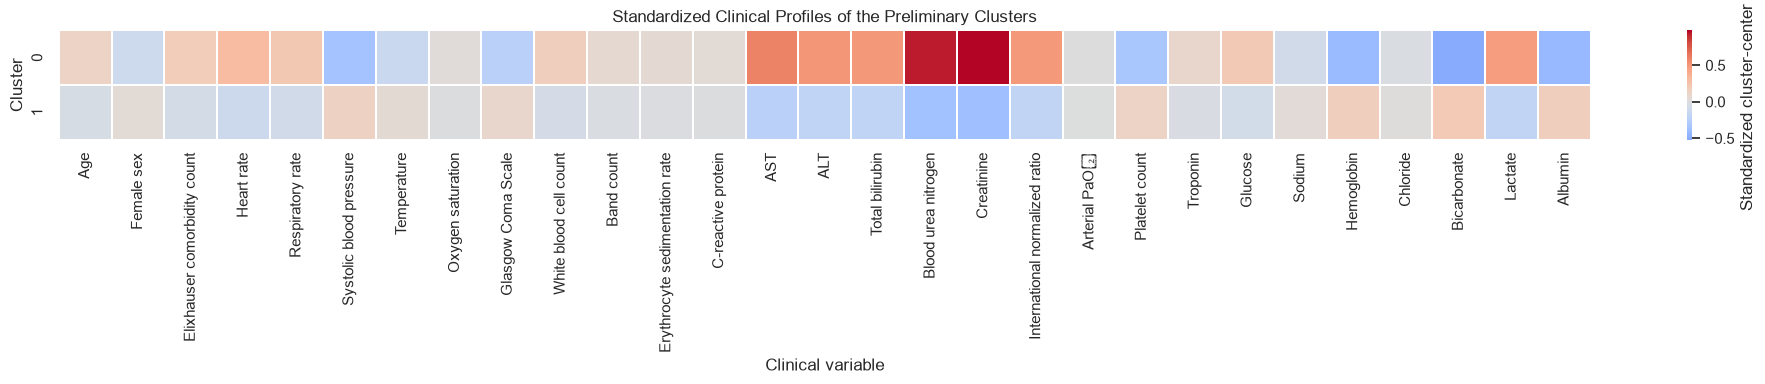

In [14]:
heatmap_data = (
    standardized_centers
    .set_index(
        "cluster"
    )[
        FEATURES
    ]
    .rename(
        columns={
            feature: (
                VARIABLE_INFO[
                    feature
                ][0]
            )
            for feature in FEATURES
        }
    )
)


plt.figure(
    figsize=(
        20,
        max(
            4,
            SELECTED_K + 2,
        ),
    )
)


sns.heatmap(
    heatmap_data,

    cmap="coolwarm",

    center=0,

    linewidths=0.25,

    cbar_kws={
        "label": (
            "Standardized cluster-center value"
        )
    },
)


plt.title(
    "Standardized Clinical Profiles "
    "of the Preliminary Clusters"
)

plt.xlabel(
    "Clinical variable"
)

plt.ylabel(
    "Cluster"
)


plt.tight_layout()


plt.savefig(
    PLOTS_DIR
    / "cluster_profile_heatmap.png",

    dpi=300,
    bbox_inches="tight",
)


plt.show()

#### Explanation :
This is the main required figure :
- Positive values indicate that the cluster is above the overall standardized average.
- Negative values indicate that the cluster is below the overall standardized average.
- Values close to zero indicate that the cluster is close to the cohort average.

### Plot the Top Distinguishing Variables

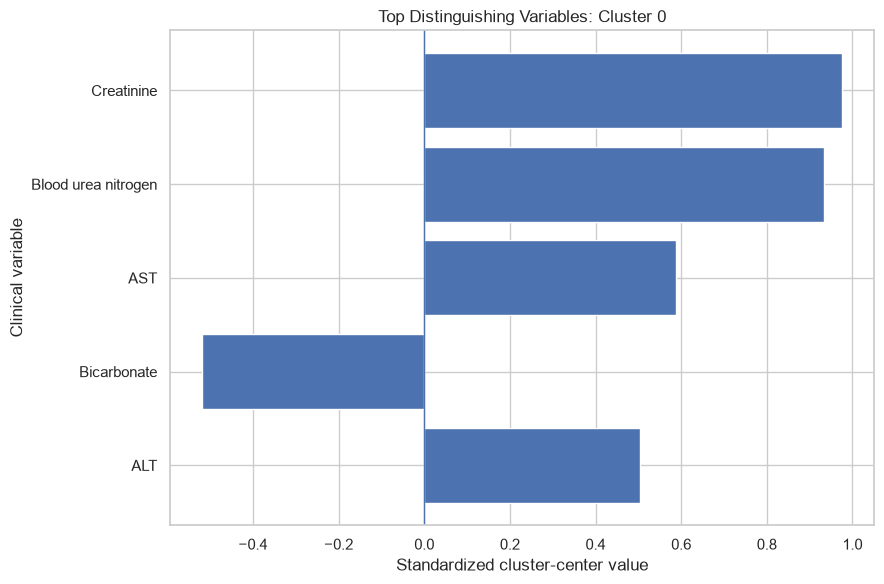

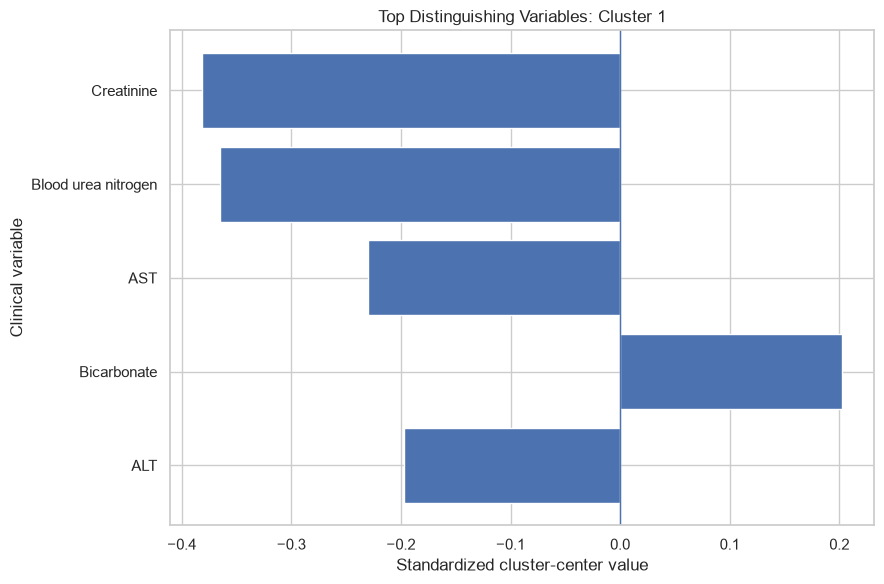

In [15]:
for cluster in CLUSTERS:

    plot_data = (
        distinguishing_variables[
            distinguishing_variables[
                "cluster"
            ]
            == cluster
        ]
        .sort_values(
            "absolute_center_value",
            ascending=True,
        )
    )


    figure, axis = plt.subplots(
        figsize=(
            9,
            6,
        )
    )


    axis.barh(
        plot_data[
            "display_name"
        ],

        plot_data[
            "standardized_center_value"
        ],
    )


    axis.axvline(
        0,
        linewidth=1,
    )


    axis.set_title(
        f"Top Distinguishing Variables: "
        f"Cluster {cluster}"
    )


    axis.set_xlabel(
        "Standardized cluster-center value"
    )


    axis.set_ylabel(
        "Clinical variable"
    )


    figure.tight_layout()


    figure.savefig(
        TOP_VARIABLE_PLOTS_DIR
        / (
            "top_distinguishing_variables_"
            f"cluster_{cluster}.png"
        ),

        dpi=300,
        bbox_inches="tight",
    )


    plt.show()

#### Explanation :
One Horizontal bar chart is created for each cluster. These figures shows the strongest above-average and below-average cluster characteristics.

### Create Brief Descriptive Interpretations

In [16]:
def direction_phrase(
    row,
):
    """
    Convert a center value into a readable phrase.
    """

    if (
        row[
            "standardized_center_value"
        ]
        > 0
    ):

        return (
            f"higher "
            f"{row['display_name'].lower()}"
        )


    return (
        f"lower "
        f"{row['display_name'].lower()}"
    )


interpretation_rows = []


for cluster in CLUSTERS:

    current = (
        distinguishing_variables[
            distinguishing_variables[
                "cluster"
            ]
            == cluster
        ]
        .sort_values(
            "rank_within_cluster"
        )
    )


    feature_phrases = [
        direction_phrase(
            row
        )
        for _, row in current.iterrows()
    ]


    # Working interpretations for the selected two-cluster solution
    if (
        SELECTED_K == 2
        and cluster == 0
    ):

        working_label = (
            "Greater multiorgan dysfunction profile"
        )


        interpretation = (
            "This cluster shows a greater burden of "
            "renal, hepatic, metabolic, hematologic, "
            "and circulatory abnormalities relative "
            "to the overall cohort. The interpretation "
            "is descriptive and should not be treated "
            "as a confirmed diagnosis."
        )


    elif (
        SELECTED_K == 2
        and cluster == 1
    ):

        working_label = (
            "Comparatively lower organ dysfunction profile"
        )


        interpretation = (
            "This cluster shows comparatively less "
            "pronounced renal, hepatic, metabolic, "
            "hematologic, and circulatory abnormalities. "
            "This is a relative comparison within an ICU "
            "cohort and does not imply that the ICU stays "
            "were clinically normal."
        )


    else:

        working_label = (
            f"Cluster {cluster} clinical profile"
        )


        if feature_phrases:

            profile_text = (
                ", ".join(
                    feature_phrases[:-1]
                )
                +
                (
                    f", and "
                    f"{feature_phrases[-1]}"
                    if len(feature_phrases) > 1
                    else feature_phrases[-1]
                )
            )

        else:

            profile_text = (
                "no clearly distinguishing variables"
            )


        interpretation = (
            "The strongest standardized characteristics "
            f"are {profile_text}. "
            "This description is preliminary and exploratory."
        )


    interpretation_rows.append(
        {
            "cluster": cluster,

            "working_description": (
                working_label
            ),

            "top_distinguishing_features": (
                "; ".join(
                    feature_phrases
                )
            ),

            "brief_interpretation": (
                interpretation
            ),
        }
    )


cluster_interpretation_summary = pd.DataFrame(
    interpretation_rows
)


cluster_interpretation_summary.to_csv(
    RESULTS_DIR
    / "cluster_interpretation_summary.csv",
    index=False,
)


cluster_interpretation_summary

,cluster,working_description,top_distinguishing_features,brief_interpretation
0,0,Greater multiorgan dysfunction profile,higher creatinine; higher blood urea nitrogen;...,"This cluster shows a greater burden of renal, ..."
1,1,Comparatively lower organ dysfunction profile,lower creatinine; lower blood urea nitrogen; l...,This cluster shows comparatively less pronounc...


#### Explanation :
The cluster descriptions are cautious working interpretations. They do not claim that the groups are confirmed disease phenotypes.

### Optional Exploratory Outcome Comparisons

In [17]:
def simplify_name(
    name,
):
    """
    Simplify names for case-insensitive file matching.
    """

    return re.sub(
        r"[^a-z0-9]",
        "",
        str(
            name
        ).lower(),
    )


def find_csv_file(
    folder,
    expected_stem,
):
    """
    Find one CSV file using a punctuation-insensitive name.
    """

    expected = simplify_name(
        expected_stem
    )


    matches = [
        path
        for path in folder.glob(
            "*.csv"
        )
        if simplify_name(
            path.stem
        )
        == expected
    ]


    if len(matches) == 1:
        return matches[
            0
        ]


    if len(matches) > 1:

        raise FileExistsError(
            f"Multiple files matched "
            f"{expected_stem}:\n"
            f"{matches}"
        )


    return None


def convert_status_to_binary(
    series,
):
    """
    Convert eICU discharge status to death=1 and alive=0.
    """

    text = (
        series
        .astype(
            "string"
        )
        .str.strip()
        .str.lower()
    )


    result = pd.Series(
        np.nan,
        index=series.index,
        dtype=float,
    )


    expired = text.str.contains(
        r"expired|dead|death",
        regex=True,
        na=False,
    )


    alive = text.str.contains(
        r"alive",
        regex=True,
        na=False,
    )


    result.loc[
        expired
    ] = 1.0


    result.loc[
        alive
    ] = 0.0


    return result


outcome_comparison_summary = pd.DataFrame()

outcome_test_results = pd.DataFrame()


patient_path = find_csv_file(
    PROCESSED_DIR,
    "patient",
)


# Confirm these outcomes were not clustering inputs
OUTCOME_VARIABLES = {
    "icu_mortality",
    "hospital_mortality",
    "icu_length_of_stay_days",
    "hospital_length_of_stay_days",
}


assert OUTCOME_VARIABLES.isdisjoint(
    FEATURES
)


if (
    INCLUDE_EXPLORATORY_OUTCOMES
    and patient_path is not None
):

    patient_header = pd.read_csv(
        patient_path,
        nrows=0,
    ).columns.tolist()


    header_lookup = {
        column.lower(): column
        for column in patient_header
    }


    desired_columns = [
        ID_COLUMN,
        "unitDischargeStatus",
        "unitDischargeOffset",
        "hospitalAdmitOffset",
        "hospitalDischargeStatus",
        "hospitalDischargeOffset",
    ]


    available_columns = [
        header_lookup[
            column.lower()
        ]
        for column in desired_columns
        if column.lower() in header_lookup
    ]


    if (
        ID_COLUMN.lower() in header_lookup
        and len(available_columns) > 1
    ):

        patient_outcomes = pd.read_csv(
            patient_path,
            usecols=available_columns,
            low_memory=False,
        )


        patient_outcomes.columns = (
            patient_outcomes
            .columns
            .str.lower()
        )


        patient_outcomes[
            ID_COLUMN
        ] = pd.to_numeric(
            patient_outcomes[
                ID_COLUMN
            ],
            errors="coerce",
        )


        if patient_outcomes[
            ID_COLUMN
        ].duplicated().any():

            raise ValueError(
                "The patient outcome table contains "
                "duplicate patientunitstayid values."
            )


        # -------------------------------------------------
        # ICU mortality
        # -------------------------------------------------
        if (
            "unitdischargestatus"
            in patient_outcomes.columns
        ):

            patient_outcomes[
                "icu_mortality"
            ] = convert_status_to_binary(
                patient_outcomes[
                    "unitdischargestatus"
                ]
            )


        # -------------------------------------------------
        # Hospital mortality
        # -------------------------------------------------
        if (
            "hospitaldischargestatus"
            in patient_outcomes.columns
        ):

            patient_outcomes[
                "hospital_mortality"
            ] = convert_status_to_binary(
                patient_outcomes[
                    "hospitaldischargestatus"
                ]
            )


        # -------------------------------------------------
        # ICU length of stay
        # unitDischargeOffset is measured from ICU admission.
        # -------------------------------------------------
        if (
            "unitdischargeoffset"
            in patient_outcomes.columns
        ):

            patient_outcomes[
                "icu_length_of_stay_days"
            ] = (
                pd.to_numeric(
                    patient_outcomes[
                        "unitdischargeoffset"
                    ],
                    errors="coerce",
                )
                / 1440
            )


            patient_outcomes.loc[
                patient_outcomes[
                    "icu_length_of_stay_days"
                ]
                < 0,

                "icu_length_of_stay_days",
            ] = np.nan


        # -------------------------------------------------
        # Full hospital length of stay
        #
        # Both offsets are relative to ICU admission:
        # hospital LOS = discharge offset - admission offset
        # -------------------------------------------------
        required_hospital_offsets = {
            "hospitaladmitoffset",
            "hospitaldischargeoffset",
        }


        if required_hospital_offsets.issubset(
            patient_outcomes.columns
        ):

            hospital_admit_offset = pd.to_numeric(
                patient_outcomes[
                    "hospitaladmitoffset"
                ],
                errors="coerce",
            )


            hospital_discharge_offset = pd.to_numeric(
                patient_outcomes[
                    "hospitaldischargeoffset"
                ],
                errors="coerce",
            )


            patient_outcomes[
                "hospital_length_of_stay_days"
            ] = (
                hospital_discharge_offset
                - hospital_admit_offset
            ) / 1440


            patient_outcomes.loc[
                patient_outcomes[
                    "hospital_length_of_stay_days"
                ]
                < 0,

                "hospital_length_of_stay_days",
            ] = np.nan


        # -------------------------------------------------
        # Merge outcomes with selected clusters
        # -------------------------------------------------
        outcome_data = cluster_data[
            [
                ID_COLUMN,
                CLUSTER_COLUMN,
            ]
        ].merge(
            patient_outcomes,
            on=ID_COLUMN,
            how="left",
            validate="one_to_one",
        )


        mortality_variables = [
            variable
            for variable in [
                "icu_mortality",
                "hospital_mortality",
            ]
            if variable in outcome_data.columns
        ]


        length_of_stay_variables = [
            variable
            for variable in [
                "icu_length_of_stay_days",
                "hospital_length_of_stay_days",
            ]
            if variable in outcome_data.columns
        ]


        outcome_rows = []

        test_rows = []


        # -------------------------------------------------
        # Mortality summaries and chi-square tests
        # -------------------------------------------------
        for variable in mortality_variables:

            for cluster in CLUSTERS:

                values = outcome_data.loc[
                    outcome_data[
                        CLUSTER_COLUMN
                    ]
                    == cluster,

                    variable,
                ].dropna()


                outcome_rows.append(
                    {
                        "outcome": variable,

                        "cluster": cluster,

                        "summary_type": (
                            "N (%)"
                        ),

                        "available_n": int(
                            values.count()
                        ),

                        "event_count": int(
                            values.sum()
                        ),

                        "event_percent": float(
                            values.mean()
                            * 100
                        ),

                        "median": np.nan,

                        "q1": np.nan,

                        "q3": np.nan,
                    }
                )


            contingency = pd.crosstab(
                outcome_data[
                    CLUSTER_COLUMN
                ],

                outcome_data[
                    variable
                ],
            )


            if (
                contingency.shape[0] >= 2
                and contingency.shape[1] == 2
            ):

                (
                    statistic,
                    p_value,
                    _,
                    _,
                ) = chi2_contingency(
                    contingency
                )


                test_rows.append(
                    {
                        "outcome": variable,

                        "test": (
                            "Chi-square test"
                        ),

                        "statistic": statistic,

                        "p_value": p_value,

                        "interpretation": (
                            "Exploratory association only; "
                            "not proof of clinical validity "
                            "or causality"
                        ),
                    }
                )


        # -------------------------------------------------
        # Length-of-stay summaries and tests
        # -------------------------------------------------
        for variable in length_of_stay_variables:

            groups = []


            for cluster in CLUSTERS:

                values = outcome_data.loc[
                    outcome_data[
                        CLUSTER_COLUMN
                    ]
                    == cluster,

                    variable,
                ].dropna()


                groups.append(
                    values
                )


                outcome_rows.append(
                    {
                        "outcome": variable,

                        "cluster": cluster,

                        "summary_type": (
                            "Median [IQR]"
                        ),

                        "available_n": int(
                            values.count()
                        ),

                        "event_count": np.nan,

                        "event_percent": np.nan,

                        "median": float(
                            values.median()
                        ),

                        "q1": float(
                            values.quantile(
                                0.25
                            )
                        ),

                        "q3": float(
                            values.quantile(
                                0.75
                            )
                        ),
                    }
                )


            if all(
                len(
                    group
                )
                > 0
                for group in groups
            ):

                if len(groups) == 2:

                    (
                        statistic,
                        p_value,
                    ) = mannwhitneyu(
                        groups[0],
                        groups[1],
                        alternative="two-sided",
                    )


                    test_name = (
                        "Mann–Whitney U test"
                    )


                else:

                    (
                        statistic,
                        p_value,
                    ) = kruskal(
                        *groups
                    )


                    test_name = (
                        "Kruskal–Wallis test"
                    )


                test_rows.append(
                    {
                        "outcome": variable,

                        "test": test_name,

                        "statistic": statistic,

                        "p_value": p_value,

                        "interpretation": (
                            "Exploratory association only; "
                            "not proof of clinical validity "
                            "or causality"
                        ),
                    }
                )


        outcome_comparison_summary = pd.DataFrame(
            outcome_rows
        )


        outcome_test_results = pd.DataFrame(
            test_rows
        )


        outcome_comparison_summary.to_csv(
            RESULTS_DIR
            / "outcome_comparison_summary.csv",
            index=False,
        )


        outcome_test_results.to_csv(
            RESULTS_DIR
            / "outcome_statistical_tests.csv",
            index=False,
        )


        print(
            "Exploratory outcome summaries were created."
        )


    else:

        print(
            "The patient table does not contain "
            "enough outcome columns."
        )


else:

    print(
        "Exploratory outcome comparisons were skipped."
    )

Exploratory outcome summaries were created.


#### Explanation :
This section optionally compares :
- ICU mortality
- Hospital mortality
- ICU length of stay
- Hospital length of stay

These variables were not used to create the clusters.

The outcome results must be treated as descriptive and exploratory.

### Plot Mortality Outcomes When Available

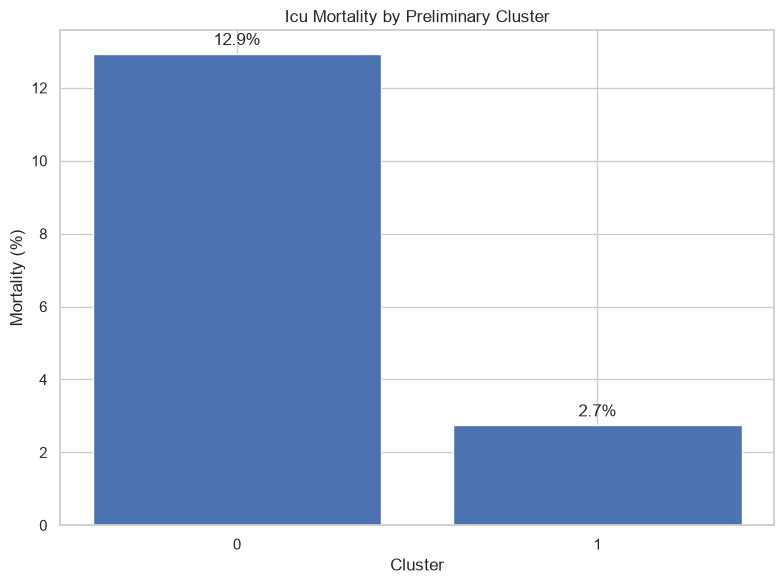

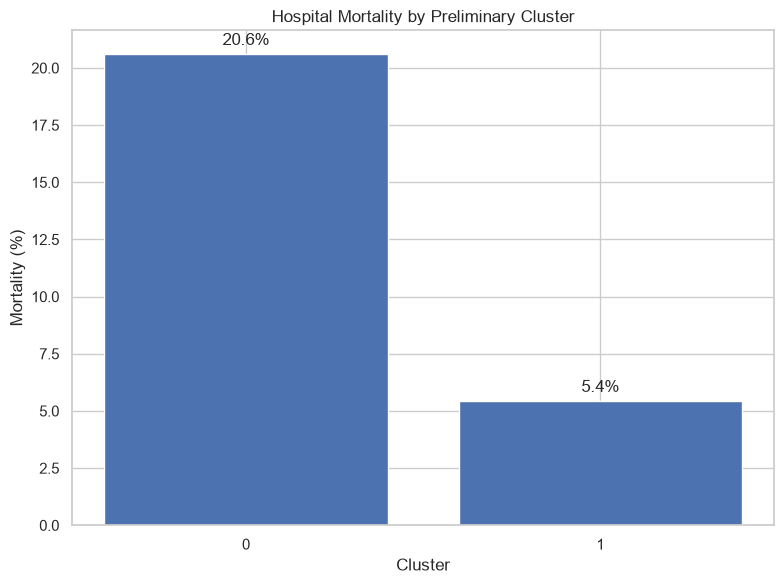

In [18]:
if not outcome_comparison_summary.empty:

    mortality_plot_data = (
        outcome_comparison_summary[
            outcome_comparison_summary[
                "outcome"
            ]
            .isin(
                [
                    "icu_mortality",
                    "hospital_mortality",
                ]
            )
        ]
        .copy()
    )


    for outcome in (
        mortality_plot_data[
            "outcome"
        ]
        .unique()
    ):

        plot_data = (
            mortality_plot_data[
                mortality_plot_data[
                    "outcome"
                ]
                == outcome
            ]
            .sort_values(
                "cluster"
            )
        )


        figure, axis = plt.subplots(
            figsize=(
                8,
                6,
            )
        )


        bars = axis.bar(
            plot_data[
                "cluster"
            ].astype(str),

            plot_data[
                "event_percent"
            ],
        )


        for bar, value in zip(
            bars,
            plot_data[
                "event_percent"
            ],
        ):

            axis.annotate(
                f"{value:.1f}%",

                (
                    bar.get_x()
                    + bar.get_width()
                    / 2,

                    bar.get_height(),
                ),

                ha="center",
                va="bottom",

                xytext=(
                    0,
                    4,
                ),

                textcoords="offset points",
            )


        title = (
            outcome
            .replace(
                "_",
                " ",
            )
            .title()
        )


        axis.set_title(
            f"{title} by Preliminary Cluster"
        )


        axis.set_xlabel(
            "Cluster"
        )


        axis.set_ylabel(
            "Mortality (%)"
        )


        figure.tight_layout()


        figure.savefig(
            OUTCOME_PLOTS_DIR
            / f"{outcome}_by_cluster.png",

            dpi=300,
            bbox_inches="tight",
        )


        plt.show()


else:

    print(
        "No mortality plot was created because "
        "outcome data were unavailable."
    )

#### Explanation :
Mortality is shown as the percentage of deaths in each cluster.

The figure is exploratory and does not establish causality or clinical validity.

### Plot Length of Stay When Available

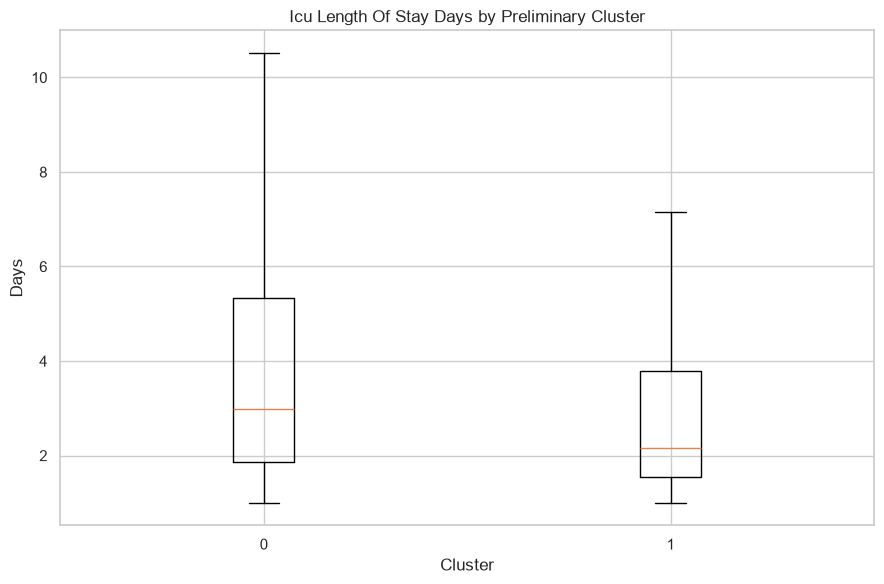

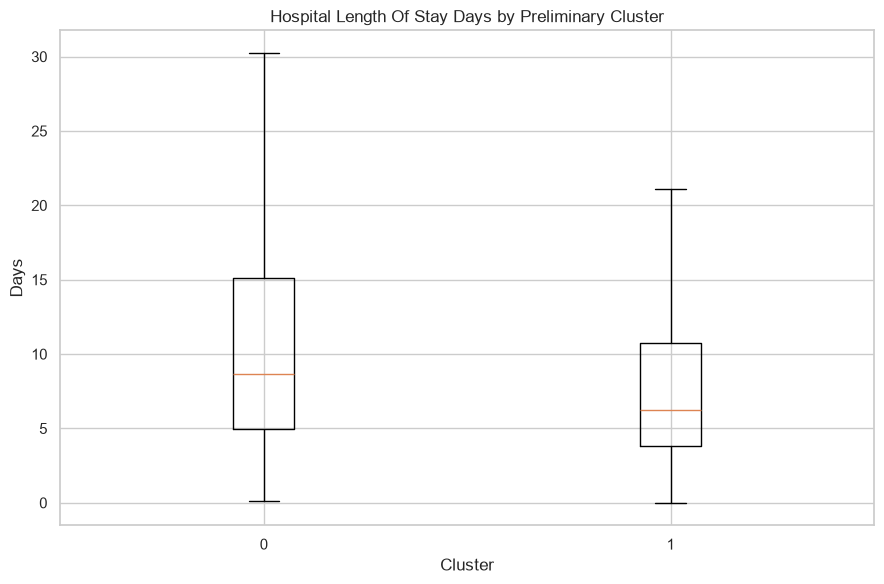

In [19]:
if "outcome_data" in globals():

    for outcome in [
        "icu_length_of_stay_days",
        "hospital_length_of_stay_days",
    ]:

        if outcome not in outcome_data.columns:
            continue


        plot_data = outcome_data[
            [
                CLUSTER_COLUMN,
                outcome,
            ]
        ].dropna().copy()


        if plot_data.empty:
            continue


        # Limit displayed values to the 99th percentile
        # so the figure remains readable.
        # The numerical summaries use all untrimmed values.
        upper_limit = plot_data[
            outcome
        ].quantile(
            0.99
        )


        display_data = plot_data[
            plot_data[
                outcome
            ]
            <= upper_limit
        ]


        boxplot_values = [
            display_data.loc[
                display_data[
                    CLUSTER_COLUMN
                ]
                == cluster,

                outcome,
            ].to_numpy()

            for cluster in CLUSTERS
        ]


        figure, axis = plt.subplots(
            figsize=(
                9,
                6,
            )
        )


        axis.boxplot(
            boxplot_values,

            tick_labels=[
                str(
                    cluster
                )
                for cluster in CLUSTERS
            ],

            showfliers=False,
        )


        title = (
            outcome
            .replace(
                "_",
                " ",
            )
            .title()
        )


        axis.set_title(
            f"{title} by Preliminary Cluster"
        )


        axis.set_xlabel(
            "Cluster"
        )


        axis.set_ylabel(
            "Days"
        )


        figure.tight_layout()


        figure.savefig(
            OUTCOME_PLOTS_DIR
            / f"{outcome}_by_cluster.png",

            dpi=300,
            bbox_inches="tight",
        )


        plt.show()


else:

    print(
        "No length-of-stay plot was created because "
        "outcome data were unavailable."
    )

#### Explanation :
Length of stay is shown with box plots because it is generally skewed.

The displayed plot excludes values above the $99\text{th}$ percentile only for readability. The CSV summaries continue to use the complete, untrimmed data.

### Run Final Integrity Checks

In [20]:
# One row per ICU stay
assert cluster_data[
    ID_COLUMN
].is_unique, (
    "The merged Task 7 dataset contains "
    "duplicate ICU stay identifiers."
)


# Every row must have a cluster assignment
assert cluster_data[
    CLUSTER_COLUMN
].notna().all(), (
    "The merged Task 7 dataset contains "
    "missing cluster assignments."
)


# Cluster labels must agree with the center table
assert set(
    CLUSTERS
) == set(
    standardized_centers[
        "cluster"
    ].tolist()
), (
    "Cluster labels do not match between "
    "assignments and standardized centers."
)


# Two size rows plus 29 variables
assert len(
    cluster_characteristics_table
) == (
    len(FEATURES)
    + 2
), (
    "The main characteristics table should contain "
    "two size rows plus 29 variables."
)


# Every cluster must have distinguishing variables
assert set(
    distinguishing_variables[
        "cluster"
    ].unique()
) == set(
    CLUSTERS
), (
    "The distinguishing-variable table is "
    "missing a cluster."
)


# The clinical matrix must contain all selected features
assert all(
    feature
    in cluster_data.columns
    for feature in FEATURES
), (
    "One or more selected clinical variables "
    "are missing."
)


print(
    "All Task 7 integrity checks passed successfully."
)

All Task 7 integrity checks passed successfully.


#### Explanation :
These checks confirm that :
- ICU stay identifiers are unique.
- Cluster assignments are complete.
- Cluster labels match the center table.
- The main table includes all $29$ variables.
- Every cluster has distinguishing variables.

### Display the Final Required Results

In [21]:
print(
    "CLUSTER SIZE SUMMARY"
)

display(
    cluster_size_summary
)


print(
    "\nMAIN CLUSTER-CHARACTERISTICS TABLE"
)

display(
    cluster_characteristics_table
)


print(
    "\nTOP DISTINGUISHING VARIABLES"
)

display(
    distinguishing_variables
)


print(
    "\nBRIEF CLUSTER INTERPRETATIONS"
)

display(
    cluster_interpretation_summary
)


if not outcome_comparison_summary.empty:

    print(
        "\nEXPLORATORY OUTCOME COMPARISONS"
    )

    display(
        outcome_comparison_summary
    )


if not outcome_test_results.empty:

    print(
        "\nEXPLORATORY OUTCOME TESTS"
    )

    display(
        outcome_test_results
    )

CLUSTER SIZE SUMMARY


,cluster,icu_stay_count,icu_stay_percent
0,0,32719,28.067391
1,1,83854,71.932609



MAIN CLUSTER-CHARACTERISTICS TABLE


,Variable,Unit,Summary method,Overall,Cluster 0,Cluster 1,Difference measure,Difference value,Difference direction
0,Number of ICU stays,N,Count,"116,573","32,719","83,854",,,
1,Percentage of cohort,%,Percentage,100.0%,28.1%,71.9%,,,
2,Age,years,Mean ± SD,63.92 ± 16.47,66.06 ± 15.39,63.09 ± 16.80,Cohen's d,0.181,Higher in Cluster 0
3,Female sex,N (%),N (%),"52,897 (45.4%)","13,134 (40.1%)","39,763 (47.4%)",Percentage-point difference,-7.278,Higher in Cluster 1
4,Elixhauser comorbidity count,count,Median [IQR],"1.00 [0.00, 1.00]","1.00 [0.00, 2.00]","1.00 [0.00, 1.00]",Cohen's d,0.292,Higher in Cluster 0
5,Heart rate,beats/min,Mean ± SD,85.59 ± 16.38,90.49 ± 17.25,83.67 ± 15.62,Cohen's d,0.424,Higher in Cluster 0
6,Respiratory rate,breaths/min,Median [IQR],"19.01 [16.65, 21.95]","19.71 [17.41, 23.52]","19.01 [16.43, 21.35]",Cohen's d,0.315,Higher in Cluster 0
7,Systolic blood pressure,mm Hg,Mean ± SD,119.69 ± 18.92,113.10 ± 18.36,122.27 ± 18.51,Cohen's d,-0.497,Higher in Cluster 1
8,Temperature,°C,Median [IQR],"37.12 [37.12, 37.12]","37.12 [37.12, 37.12]","37.12 [37.12, 37.12]",Cohen's d,-0.179,Higher in Cluster 1
9,Oxygen saturation,%,Median [IQR],"97.10 [95.61, 98.49]","97.29 [95.71, 98.71]","97.06 [95.57, 98.39]",Cohen's d,0.038,Higher in Cluster 0



TOP DISTINGUISHING VARIABLES


...

,cluster,working_description,top_distinguishing_features,brief_interpretation
0,0,Greater multiorgan dysfunction profile,higher creatinine; higher blood urea nitrogen;...,"This cluster shows a greater burden of renal, ..."
1,1,Comparatively lower organ dysfunction profile,lower creatinine; lower blood urea nitrogen; l...,This cluster shows comparatively less pronounc...



EXPLORATORY OUTCOME COMPARISONS


,outcome,cluster,summary_type,available_n,event_count,event_percent,median,q1,q3
0,icu_mortality,0,N (%),32714,4229.0,12.927187,NaN,NaN,NaN
1,icu_mortality,1,N (%),83853,2297.0,2.739318,NaN,NaN,NaN
2,hospital_mortality,0,N (%),32385,6674.0,20.608306,NaN,NaN,NaN
3,hospital_mortality,1,N (%),83119,4518.0,5.435580,NaN,NaN,NaN
4,icu_length_of_stay_days,0,Median [IQR],32719,NaN,NaN,3.027083,1.882639,5.581597
5,icu_length_of_stay_days,1,Median [IQR],83854,NaN,NaN,2.174306,1.550694,3.841667
6,hospital_length_of_stay_days,0,Median [IQR],32717,NaN,NaN,8.830556,5.043750,15.615972
7,hospital_length_of_stay_days,1,Median [IQR],83847,NaN,NaN,6.308333,3.809722,10.845139



EXPLORATORY OUTCOME TESTS


,outcome,test,statistic,p_value,interpretation
0,icu_mortality,Chi-square test,4.619680e+03,0.0,Exploratory association only; not proof of cli...
1,hospital_mortality,Chi-square test,6.129198e+03,0.0,Exploratory association only; not proof of cli...
2,icu_length_of_stay_days,Mann–Whitney U test,1.674214e+09,0.0,Exploratory association only; not proof of cli...
3,hospital_length_of_stay_days,Mann–Whitney U test,1.672948e+09,0.0,Exploratory association only; not proof of cli...


#### Explanation :
This cell displays the final cluster sizes, clinical characteristics, distinguishing variables, interpretations and optional exploratory outcome comparisons.

### Display the Final Summary

In [22]:
print("=" * 100)
print(
    "TASK 7: CLUSTER DESCRIPTION "
    "AND INTERPRETATION COMPLETED"
)
print("=" * 100)


print(
    f"Number of ICU stays          : "
    f"{len(cluster_data):,}"
)


print(
    f"Selected number of clusters  : "
    f"{SELECTED_K}"
)


print(
    f"Clinical variables reported  : "
    f"{len(FEATURES)}"
)


print("-" * 100)


print(
    "Required main table:"
)

print(
    RESULTS_DIR
    / "cluster_characteristics_table.csv"
)


print(
    "\nRequired main figure:"
)

print(
    PLOTS_DIR
    / "cluster_profile_heatmap.png"
)


print(
    "\nCluster-size figure:"
)

print(
    PLOTS_DIR
    / "cluster_size_distribution.png"
)


print(
    "\nDistinguishing-variable table:"
)

print(
    RESULTS_DIR
    / "distinguishing_variables.csv"
)


print(
    "\nCluster interpretations:"
)

print(
    RESULTS_DIR
    / "cluster_interpretation_summary.csv"
)


if not outcome_comparison_summary.empty:

    print(
        "\nExploratory outcome summary:"
    )

    print(
        RESULTS_DIR
        / "outcome_comparison_summary.csv"
    )


print(
    "\nSupporting results folder:"
)

print(
    RESULTS_DIR
)


print(
    "\nSupporting plots folder:"
)

print(
    PLOTS_DIR
)


print("=" * 100)

TASK 7: CLUSTER DESCRIPTION AND INTERPRETATION COMPLETED
Number of ICU stays          : 116,573
Selected number of clusters  : 2
Clinical variables reported  : 29
----------------------------------------------------------------------------------------------------
Required main table:
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_interpretation\cluster_characteristics_table.csv

Required main figure:
C:\Users\samsa\Documents\Capstone Project\Project\plots\cluster_interpretation\cluster_profile_heatmap.png

Cluster-size figure:
C:\Users\samsa\Documents\Capstone Project\Project\plots\cluster_interpretation\cluster_size_distribution.png

Distinguishing-variable table:
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_interpretation\distinguishing_variables.csv

Cluster interpretations:
C:\Users\samsa\Documents\Capstone Project\Project\results\cluster_interpretation\cluster_interpretation_summary.csv

Exploratory outcome summary:
C:\Users\samsa\Documents\

#### Explanation :
The final cell confirms that the required table and profile figure were created and shows the location of every major output.